# Points2Surf: Bunny reconstruction & SDF visualization

Load **`data/bunny.obj`**, run Points2Surf inference to predict a signed distance field (SDF), then visualize:
- input point cloud
- reconstructed mesh (marching cubes)
- 2D slices through the dense SDF volume

**Prerequisites:** `data/bunny.obj`, a checkpoint under `models/`, the `p2s` conda env, and **`rtree`** for GT signed distance (`pip install rtree` or `conda install -c conda-forge rtree libspatialindex`).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import trimesh
import trimesh.transformations as trafo

# repo root (run notebook from points2surf/)
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'source').is_dir():
    raise RuntimeError('Run this notebook from the points2surf repository root.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from source import points_to_surf_eval, sdf

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['image.cmap'] = 'RdBu_r'

RuntimeError: Run this notebook from the points2surf repository root.

## Configuration

In [ ]:
SHAPE_NAME = 'bunny'
BUNNY_OBJ = REPO_ROOT / 'data' / 'bunny.obj'

DATASET_DIR = REPO_ROOT / 'datasets' / 'bunny_demo'
OUT_DIR = REPO_ROOT / 'results' / 'notebook_bunny'

# inference / reconstruction
GRID_RESOLUTION = 128   # use 256 for paper-quality (slower)
REC_EPSILON = 20
SIGMA = 5
CERTAINTY_THRESHOLD = 13
BATCH_SIZE = 100
GPU_IDX = 0             # set < 0 for CPU
NUM_POINTS = 50000      # subsample mesh vertices for the input point cloud

# model checkpoint (must exist under models/)
MODEL_NAME = 'p2s_max'
MODEL_POSTFIX = '_model_249.pth'
PARAM_POSTFIX = '_params.pth'   # from vanilla model zip (not _params_149.pth)
MODEL_DIR = REPO_ROOT / 'models'

## 1. Load bunny.obj and build input point cloud

Meshes are centered and scaled to the **[-1, 1]³** unit cube (same as the training pipeline).

In [ ]:
def to_unit_cube(mesh: trimesh.Trimesh) -> trimesh.Trimesh:
    mesh = mesh.copy()
    center = (mesh.bounds[0] + mesh.bounds[1]) * 0.5
    mesh.apply_transform(trafo.translation_matrix(-center))
    scale = 1.0 / mesh.extents.max()
    mesh.apply_transform(trafo.scale_matrix(scale))
    return mesh


if not BUNNY_OBJ.is_file():
    raise FileNotFoundError(f'Expected mesh at {BUNNY_OBJ}')

mesh_gt = to_unit_cube(trimesh.load(BUNNY_OBJ, force='mesh'))
pts = mesh_gt.vertices[:, :3].astype(np.float32)
if NUM_POINTS and pts.shape[0] > NUM_POINTS:
    rng = np.random.default_rng(42)
    pts = pts[rng.choice(pts.shape[0], NUM_POINTS, replace=False)]

pts_dir = DATASET_DIR / '04_pts'
pts_dir.mkdir(parents=True, exist_ok=True)
np.save(pts_dir / f'{SHAPE_NAME}.xyz.npy', pts)
np.savetxt(pts_dir / f'{SHAPE_NAME}.xyz', pts)

testset_file = DATASET_DIR / 'testset.txt'
testset_file.write_text(f'{SHAPE_NAME}\n')

print(f'Point cloud: {pts.shape[0]} points, bounds [{pts.min():.3f}, {pts.max():.3f}]')

Point cloud: 34834 points, bounds [-0.500, 0.500]


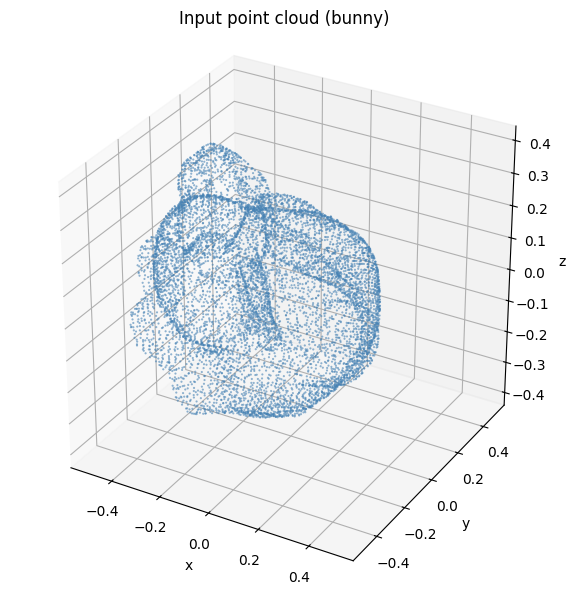

In [ ]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
step = max(1, pts.shape[0] // 8000)
ax.scatter(pts[::step, 0], pts[::step, 1], pts[::step, 2], s=0.3, c='steelblue', alpha=0.6)
ax.set_title('Input point cloud (bunny)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_box_aspect([1, 1, 1])
plt.tight_layout()
plt.show()

## 2. Run Points2Surf inference (SDF on grid)

In [ ]:
model_file = MODEL_DIR / f'{MODEL_NAME}{MODEL_POSTFIX}'
param_file = MODEL_DIR / f'{MODEL_NAME}{PARAM_POSTFIX}'
if not model_file.is_file() or not param_file.is_file():
    raise FileNotFoundError(f'Expected checkpoint at {model_file} and {param_file}')

print(f'Using model: {model_file.name}')

eval_args = [
    '--indir', str(DATASET_DIR),
    '--outdir', str(OUT_DIR),
    '--dataset', 'testset.txt',
    '--models', MODEL_NAME,
    '--modelpostfix', MODEL_POSTFIX,
    '--parampostfix', PARAM_POSTFIX,
    '--reconstruction', 'True',
    '--query_grid_resolution', str(GRID_RESOLUTION),
    '--epsilon', str(REC_EPSILON),
    '--batchSize', str(BATCH_SIZE),
    '--workers', '0',
    '--cache_capacity', '1',
    '--gpu_idx', str(GPU_IDX),
]
eval_opt = points_to_surf_eval.parse_arguments(eval_args)
points_to_surf_eval.points_to_surf_eval(eval_opt)

rec_dir = OUT_DIR / 'rec'
dist_file = rec_dir / 'dist_ms' / f'{SHAPE_NAME}.xyz.npy'
query_file = rec_dir / 'query_pts_ms' / f'{SHAPE_NAME}.xyz.npy'
query_dist_ms = np.load(dist_file)
query_pts_ms = np.load(query_file)
print(f'Predicted SDF samples: {query_dist_ms.shape[0]} query points')

Using model: p2s_max_model_249.pth
Random Seed: 40938661
getting information for 1 shapes


evaluating 276108 patches


100%|██████████| 2762/2762 [02:41<00:00, 17.09it/s]

Predicted SDF samples: 276108 query points


## 3. Sparse SDF → dense sign field → mesh

**What the network predicts:** signed distance at sparse grid points near the surface (`query_pts_ms`, `query_dist_ms`). That is the actual SDF output.

**What the slice plots used to show:** after `propagate_sign`, empty voxels are filled with **±1** (inside/outside only). Marching cubes needs that dense sign field; it is **not** a full Euclidean SDF in the volume interior.

Below we keep both: `volume_sparse` (network SDF on the grid shell) and `volume_dense` (sign-filled, used for meshing).

In [ ]:
vol_dir = rec_dir / 'vol'
mesh_dir = rec_dir / 'mesh'
vol_dir.mkdir(parents=True, exist_ok=True)
mesh_dir.mkdir(parents=True, exist_ok=True)

vol_path = vol_dir / f'{SHAPE_NAME}.off'
mesh_path = mesh_dir / f'{SHAPE_NAME}.ply'

sdf.implicit_surface_to_mesh(
    query_dist_ms=query_dist_ms,
    query_pts_ms=query_pts_ms,
    volume_out_file=str(vol_path),
    mc_out_file=str(mesh_path),
    grid_res=GRID_RESOLUTION,
    sigma=SIGMA,
    certainty_threshold=CERTAINTY_THRESHOLD,
)

# sparse grid SDF (network values only; 0 = no sample at this voxel)
volume_sparse = np.zeros((GRID_RESOLUTION, GRID_RESOLUTION, GRID_RESOLUTION), dtype=np.float32)
volume_sparse = sdf.add_samples_to_volume(volume_sparse, query_pts_ms, query_dist_ms)

# dense sign field for marching cubes (unknown voxels → ±1, not true distance)
volume_dense = volume_sparse.copy()
volume_dense = sdf.propagate_sign(volume_dense, sigma=SIGMA, certainty_threshold=CERTAINTY_THRESHOLD)
volume_dense = np.clip(volume_dense, -1.0, 1.0)

mesh_rec = trimesh.load(mesh_path) if mesh_path.is_file() else None
n_known = np.count_nonzero(volume_sparse)
n_saturated = np.sum(np.abs(volume_dense) >= 0.999)
print(f'Sparse SDF voxels (network): {n_known:,} / {volume_sparse.size:,}')
print(f'query_dist_ms: min={query_dist_ms.min():.4f}, max={query_dist_ms.max():.4f}, '
      f'|d| mean={np.abs(query_dist_ms).mean():.4f}')
print(f'Dense volume: {n_saturated:,} voxels at ±1 after sign propagation (occupancy-like)')
if mesh_rec is not None:
    print(f'Reconstructed mesh: {len(mesh_rec.vertices)} verts, {len(mesh_rec.faces)} faces')

Sign propagation took: 3.5061986446380615
Marching cubes took: 0.01826930046081543
Sparse SDF voxels (network): 276,108 / 2,097,152
query_dist_ms: min=-0.1794, max=0.1290, |d| mean=0.0634
Dense volume: 1,814,884 voxels at ±1 after sign propagation (occupancy-like)
Reconstructed mesh: 14530 verts, 28952 faces


## 4. Visualize 3D reconstruction (interactive)

Uses **Plotly** — drag to rotate, scroll to zoom, shift-drag to pan. Install if needed: `pip install plotly`

In [ ]:
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError as e:
    raise ImportError('Interactive 3D needs plotly: pip install plotly') from e

step = max(1, pts.shape[0] // 5000)
pts_vis = pts[::step]

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=('Input points', 'Reconstructed mesh'),
    horizontal_spacing=0.02,
)

fig.add_trace(
    go.Scatter3d(
        x=pts_vis[:, 0], y=pts_vis[:, 1], z=pts_vis[:, 2],
        mode='markers',
        marker=dict(size=1.5, color='steelblue', opacity=0.55),
        name='input',
    ),
    row=1, col=1,
)

if mesh_rec is not None:
    v = np.asarray(mesh_rec.vertices)
    f = np.asarray(mesh_rec.faces)
    fig.add_trace(
        go.Mesh3d(
            x=v[:, 0], y=v[:, 1], z=v[:, 2],
            i=f[:, 0], j=f[:, 1], k=f[:, 2],
            color='coral',
            opacity=0.95,
            flatshading=True,
            name='reconstruction',
        ),
        row=1, col=2,
    )

scene = dict(
    xaxis_title='x', yaxis_title='y', zaxis_title='z',
    aspectmode='data',
)
fig.update_layout(
    width=1200,
    height=600,
    showlegend=False,
    scene=scene,
    scene2=scene,
)
fig.show()

## 5. Slice views — predicted vs GT sparse SDF

Same central slices for:
- **Predicted** sparse SDF (network, splatted on the grid shell)
- **GT** sparse SDF (true signed distance from `bunny.obj` at the same query points)
- **Absolute error** = |predicted − GT| (shell only; gray = no data)

SDF rows: negative (blue) = inside, positive (red) = outside. Error row: darker = larger mistake.

Computing GT signed distance at query points...
Query-point error: MAE=0.04719, RMSE=0.05317
Grid-shell |error|: mean=0.04720, max=0.29710, p99=0.10220


/tmp/ipykernel_200936/4152789901.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


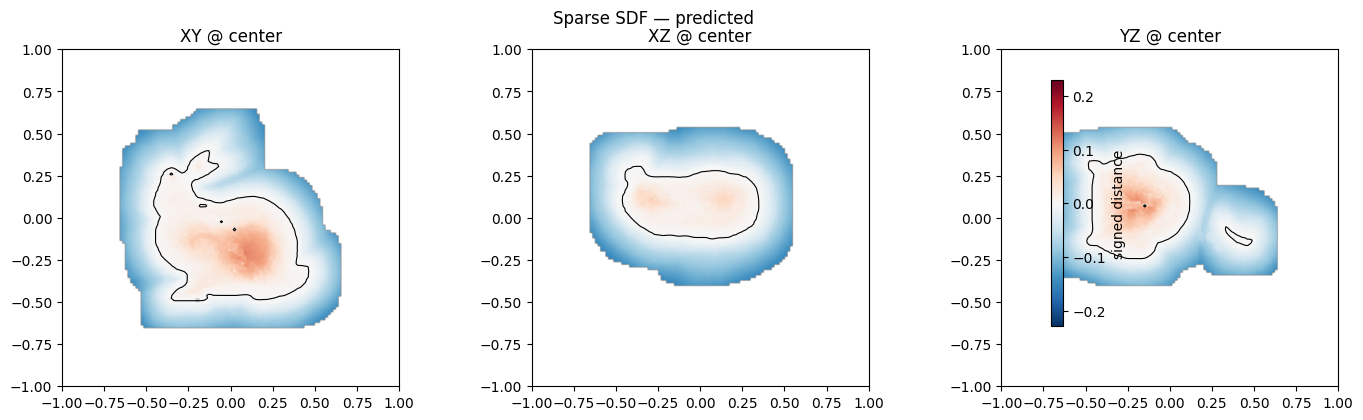

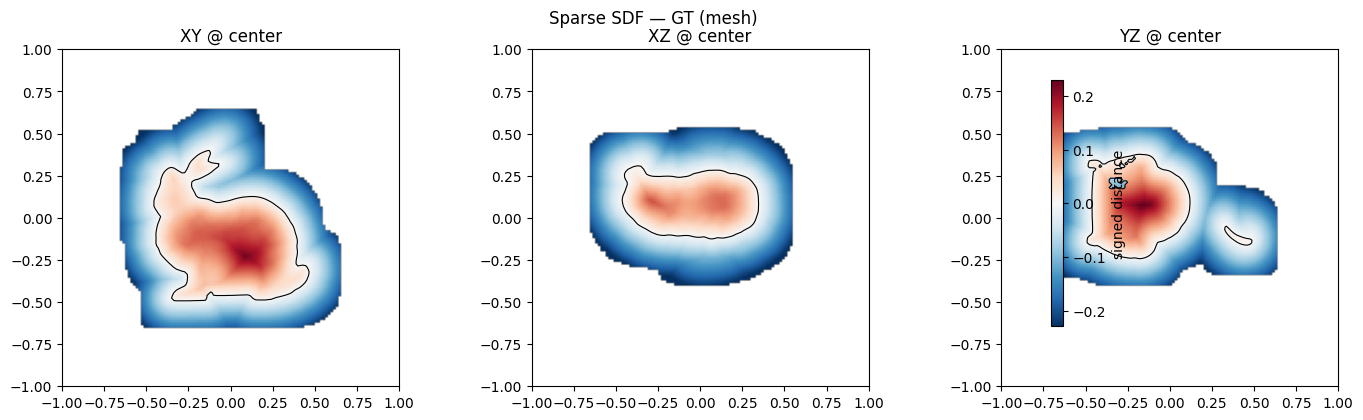

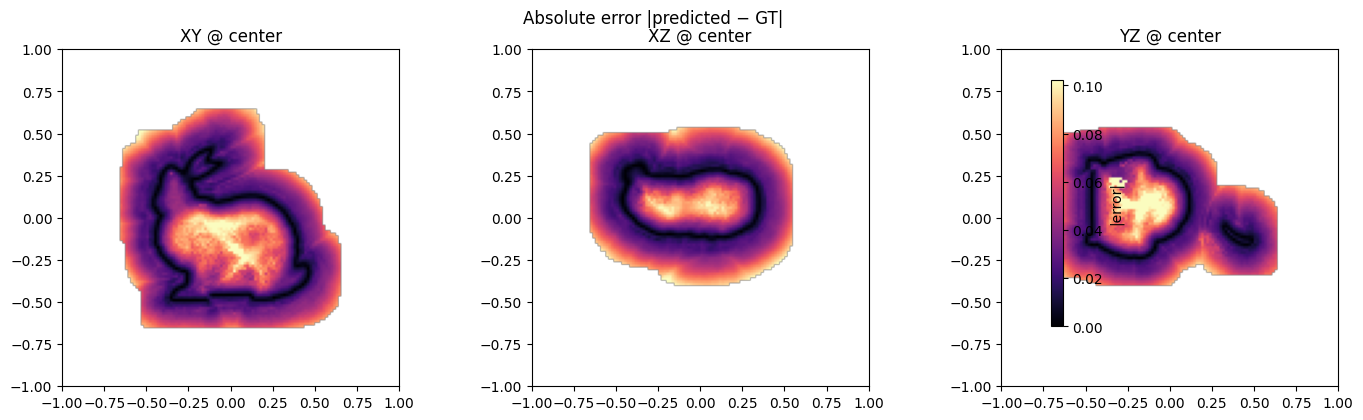

In [ ]:
def central_slices(vol):
    mid = GRID_RESOLUTION // 2
    return [
        ('XY', vol[:, :, mid].T),
        ('XZ', vol[:, mid, :].T),
        ('YZ', vol[mid, :, :].T),
    ]


def plot_slice_row(vol, title, mask_zeros=False, vmin=-1, vmax=1, cmap='RdBu_r', cbar_label='signed distance'):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (plane, sl) in zip(axes, central_slices(vol)):
        sl_plot = sl
        if mask_zeros:
            sl_plot = np.ma.masked_where(np.abs(sl) < 1e-8, sl)
        im = ax.imshow(sl_plot, origin='lower', vmin=vmin, vmax=vmax,
                       extent=[-1, 1, -1, 1], aspect='equal', cmap=cmap)
        if mask_zeros and vmin < 0:
            try:
                ax.contour(np.asarray(sl), levels=[0], colors='k', linewidths=0.8,
                           extent=[-1, 1, -1, 1], origin='lower')
            except ValueError:
                pass
        ax.set_title(f'{plane} @ center')
    fig.colorbar(im, ax=axes, label=cbar_label, shrink=0.8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

print('Computing GT signed distance at query points...')
query_dist_gt_ms = sdf.get_signed_distance(mesh_gt, query_pts_ms)
query_dist_gt_ms = np.clip(query_dist_gt_ms, -1.0, 1.0)

volume_sparse_gt = np.zeros((GRID_RESOLUTION, GRID_RESOLUTION, GRID_RESOLUTION), dtype=np.float32)
volume_sparse_gt = sdf.add_samples_to_volume(volume_sparse_gt, query_pts_ms, query_dist_gt_ms)

volume_abs_error = np.abs(volume_sparse - volume_sparse_gt)
shell = np.abs(volume_sparse) > 1e-8
err_vals = volume_abs_error[shell]

print(f'Query-point error: MAE={np.abs(query_dist_ms.ravel() - query_dist_gt_ms).mean():.5f}, '
      f'RMSE={np.sqrt(np.mean((query_dist_ms.ravel() - query_dist_gt_ms) ** 2)):.5f}')
if err_vals.size:
    print(f'Grid-shell |error|: mean={err_vals.mean():.5f}, max={err_vals.max():.5f}, '
          f'p99={np.percentile(err_vals, 99):.5f}')

dmax = np.percentile(np.abs(np.concatenate([query_dist_ms.ravel(), query_dist_gt_ms])), 99)
plot_slice_row(volume_sparse, 'Sparse SDF — predicted', mask_zeros=True, vmin=-dmax, vmax=dmax)
plot_slice_row(volume_sparse_gt, 'Sparse SDF — GT (mesh)', mask_zeros=True, vmin=-dmax, vmax=dmax)

emax = np.percentile(err_vals, 99) if err_vals.size else 0.1
plot_slice_row(volume_abs_error, 'Absolute error |predicted − GT|', mask_zeros=True,
               vmin=0, vmax=emax, cmap='magma', cbar_label='|error|')